In [1]:
import os
import random
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import ParameterGrid

In [4]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]




[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print("Path to dataset files:", path)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.68G/1.68G [03:19<00:00, 9.05MB/s]

Extracting files...


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1


In [9]:
BASE_DIR = "/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset"
SAMPLED_DIR = "./sampled_data"
GRID_SAMPLED_DIR = "./sampled_data2"
os.makedirs(SAMPLED_DIR, exist_ok=True)
os.makedirs(GRID_SAMPLED_DIR, exist_ok=True)
import os
print(os.listdir("/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset'

In [8]:
# Function to sample num_samples images per class
def sample_images(source_dir, dest_dir, num_samples):
    os.makedirs(dest_dir, exist_ok=True)
    images = [f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    selected_images = random.sample(images, min(len(images), num_samples))
    for img in selected_images:
        shutil.copy(os.path.join(source_dir, img), os.path.join(dest_dir, img))

# Select 2000 images for training, validation, and testing, 1000 for grid parameter search
for dataset in ["Train", "Validation", "Test"]:
    for label in ["Real", "Fake"]:
        source = os.path.join(BASE_DIR, dataset, label)
        dest = os.path.join(SAMPLED_DIR, dataset, label)
        dest2 = os.path.join(GRID_SAMPLED_DIR, dataset, label)
        sample_images(source, dest, 4000)
        print("Sample Images Done")
        sample_images(source, dest2, 800)
        print("Sample Grid Images Done")

Sample Images Done
Sample Grid Images Done
Sample Images Done
Sample Grid Images Done
Sample Images Done
Sample Grid Images Done
Sample Images Done
Sample Grid Images Done
Sample Images Done
Sample Grid Images Done
Sample Images Done
Sample Grid Images Done


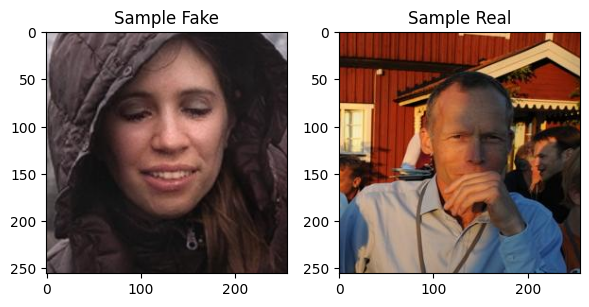

In [9]:
# Display some sample images
train_fake_dir = os.path.join(SAMPLED_DIR, "Train", "Fake")
train_real_dir = os.path.join(SAMPLED_DIR, "Train", "Real")

plt.figure(figsize=(6, 6))
plt.subplot(1,2,1)
plt.imshow(tf.keras.utils.load_img(os.path.join(train_fake_dir, os.listdir(train_fake_dir)[0])))
plt.title('Sample Fake')

plt.subplot(1,2,2)
plt.imshow(tf.keras.utils.load_img(os.path.join(train_real_dir, os.listdir(train_real_dir)[0])))
plt.title('Sample Real')

plt.tight_layout()
plt.show()

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    mode='min',
    min_delta=0.001,
    restore_best_weights=True
)

In [11]:
# Grid Model Definition

def create_model(optimiser,lr,batch_s):
    # Grid Image Data Generators
    grid_train_data = os.path.join(GRID_SAMPLED_DIR, "Train")
    grid_validation_data = os.path.join(GRID_SAMPLED_DIR, "Validation")
    grid_test_data = os.path.join(GRID_SAMPLED_DIR, "Test")

    grid_train_datagen = ImageDataGenerator(rescale=1./255)
    grid_val_datagen = ImageDataGenerator(rescale=1./255)
    grid_test_datagen = ImageDataGenerator(rescale=1./255)

    grid_train_generator = grid_train_datagen.flow_from_directory(grid_train_data,target_size=(128, 128),batch_size=batch_s,class_mode='categorical')
    grid_val_generator = grid_val_datagen.flow_from_directory(grid_validation_data,target_size=(128, 128),batch_size=batch_s,class_mode='categorical')
    grid_test_generator = grid_test_datagen.flow_from_directory(grid_test_data, target_size=(128, 128), batch_size=batch_s,class_mode='categorical')


    grid_model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        Dropout(0.20),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        BatchNormalization(),
        Dropout(0.20),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        BatchNormalization(),
        Dropout(0.20),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        BatchNormalization(),
        Dropout(0.20),

        tf.keras.layers.Flatten(),
        Dropout(0.20),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    if optimiser=="adam":
        grid_model.compile(loss="binary_crossentropy", optimizer=tf.optimizers.Adam(learning_rate=lr), metrics=['accuracy'])
    else:
        grid_model.compile(loss="binary_crossentropy", optimizer=tf.optimizers.RMSprop(learning_rate=lr), metrics=['accuracy'])
    return grid_model,grid_train_generator,grid_val_generator

In [12]:
param_grid = {
    'optimizer': ["adam","rmsprop"],
    'batch_size': [32,64],
    'learning_rate': [0.001, 0.0001]
}
grid = ParameterGrid(param_grid)

In [13]:
def train_grid_model(params):
    grid_model,train_generator,val_generator = create_model(params['optimizer'], params['learning_rate'], params['batch_size'])
    history = grid_model.fit(
        train_generator,
        epochs=20,
        validation_data=val_generator,
        verbose=1,
        callbacks=[early_stopping]
    )

    return grid_model, history

In [14]:
best_model=None
best_accuracy=0
best_params=None
val_accuracy_history={}
a=0

for params in grid:
    print(f"Training with params: {params}")
    curr_model, history = train_grid_model(params)
    val_accuracy = max(history.history['val_accuracy'])
    print(f"Validation Accuracy: {val_accuracy}\n")

    val_accuracy_history[a]=(params,history.history['val_accuracy'])
    a+=1

    if val_accuracy > best_accuracy:
        best_model = curr_model
        best_accuracy = val_accuracy
        best_params = params

Training with params: {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'adam'}
Found 1600 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.5902 - loss: 1.0097 - val_accuracy: 0.5000 - val_loss: 0.7860
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6840 - loss: 0.6563 - val_accuracy: 0.5150 - val_loss: 0.7266
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7551 - loss: 0.5486 - val_accuracy: 0.5000 - val_loss: 1.3292
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7937 - loss: 0.4279 - val_accuracy: 0.6681 - val_loss: 0.6377
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8172 - loss: 0.4132 - val_accuracy: 0.6919 - val_loss: 0.6975
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8654 - loss: 0.3261 - val_accuracy: 0.6819 - val_loss: 0.6667
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9122 - loss: 0.2436 - val_accuracy: 0.6275 - val_loss: 0.9404
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9012 - loss: 0.2478 - val_accuracy: 0.6406 - val_loss: 

/tmp/ipython-input-662183413.py:4: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(acc_history,label=params)


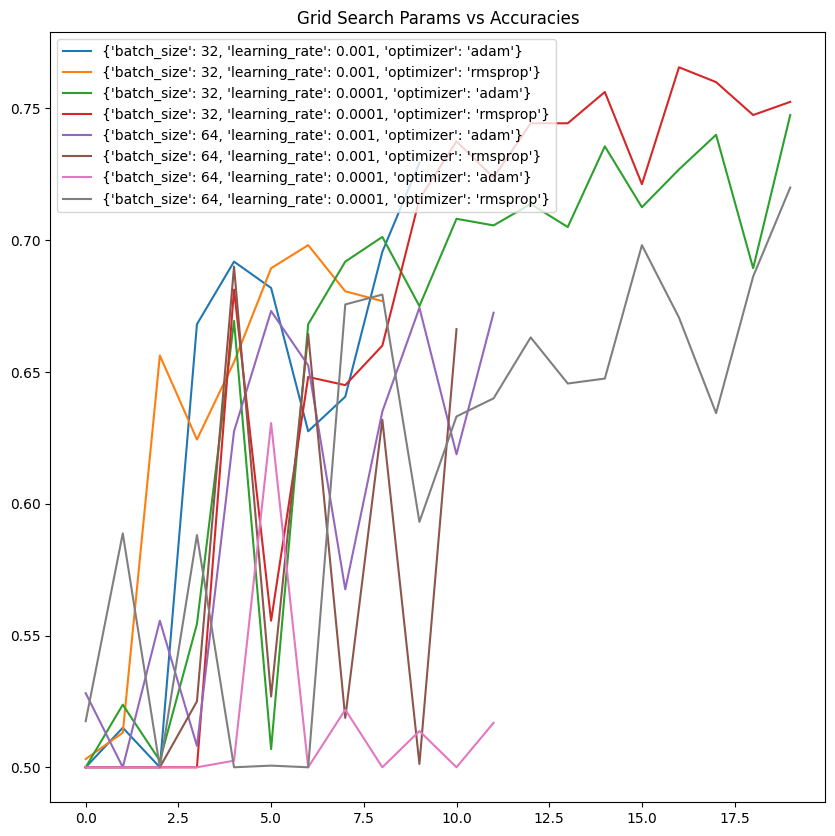

In [15]:
plt.figure(figsize=(10,10))
for i in val_accuracy_history:
    params,acc_history=val_accuracy_history[i]
    plt.plot(acc_history,label=params)
plt.title("Grid Search Params vs Accuracies")
plt.legend()
plt.show()

In [16]:
if best_model:
    print(f"Best Hyperparameters are : {best_params}")

Best Hyperparameters are : {'batch_size': 32, 'learning_rate': 0.0001, 'optimizer': 'rmsprop'}


In [17]:
# Image Data Generators
best_batch_size=best_params['batch_size']
train_data = os.path.join(SAMPLED_DIR, "Train")
validation_data = os.path.join(SAMPLED_DIR, "Validation")
test_data = os.path.join(SAMPLED_DIR, "Test")

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_data,target_size=(128, 128),batch_size=best_batch_size,class_mode='categorical')
val_generator = val_datagen.flow_from_directory(validation_data,target_size=(128, 128),batch_size=best_batch_size,class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_data, target_size=(128, 128), batch_size=best_batch_size,class_mode='categorical')

Found 8000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


In [18]:
# Model Definition
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    Dropout(0.20),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    BatchNormalization(),
    Dropout(0.20),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    BatchNormalization(),
    Dropout(0.20),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    BatchNormalization(),
    Dropout(0.20),

    tf.keras.layers.Flatten(),
    Dropout(0.20),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])
if best_params["optimizer"]=='adam':
    model.compile(loss='binary_crossentropy', optimizer=tf.optimizers.Adam(learning_rate=best_params["learning_rate"]), metrics=['accuracy'])
if best_params["optimizer"]=='rmsprop':
    model.compile(loss='binary_crossentropy', optimizer=tf.optimizers.RMSprop(learning_rate=best_params["learning_rate"]), metrics=['accuracy'])


In [ ]:
# Training the Model
history = model.fit(
    train_generator,
    epochs=20,
    verbose=1,
    callbacks=[early_stopping],
    validation_data=val_generator
)

# Saving Model
model.save("deep_fake_detector.keras")

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.6326 - loss: 0.7428 - val_accuracy: 0.5931 - val_loss: 0.7201
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.7471 - loss: 0.5522 - val_accuracy: 0.6396 - val_loss: 0.6804
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.7736 - loss: 0.4943 - val_accuracy: 0.7521 - val_loss: 0.5064
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.8017 - loss: 0.4438 - val_accuracy: 0.7691 - val_loss: 0.4879
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.8294 - loss: 0.3807 - val_accuracy: 0.7871 - val_loss: 0.4530
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8354 - loss: 0.3703 - val_accuracy: 0.7961 - val_loss: 0.4475
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8663 - loss: 0.3161 - val_accuracy: 0.8027 - val_loss: 0.4388
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.8815 - loss: 0.2806 - 

In [21]:
train_loss, train_accuracy = model.evaluate(train_generator)
val_loss, val_accuracy = model.evaluate(val_generator)
print(f"Best Model - Training Loss: {train_loss}, Training Accuracy: {train_accuracy}")
print(f"Best Model - Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9821 - loss: 0.0565
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8796 - loss: 0.3286
Best Model - Training Loss: 0.05111125856637955, Training Accuracy: 0.984000027179718
Best Model - Validation Loss: 0.32570579648017883, Validation Accuracy: 0.8803750276565552


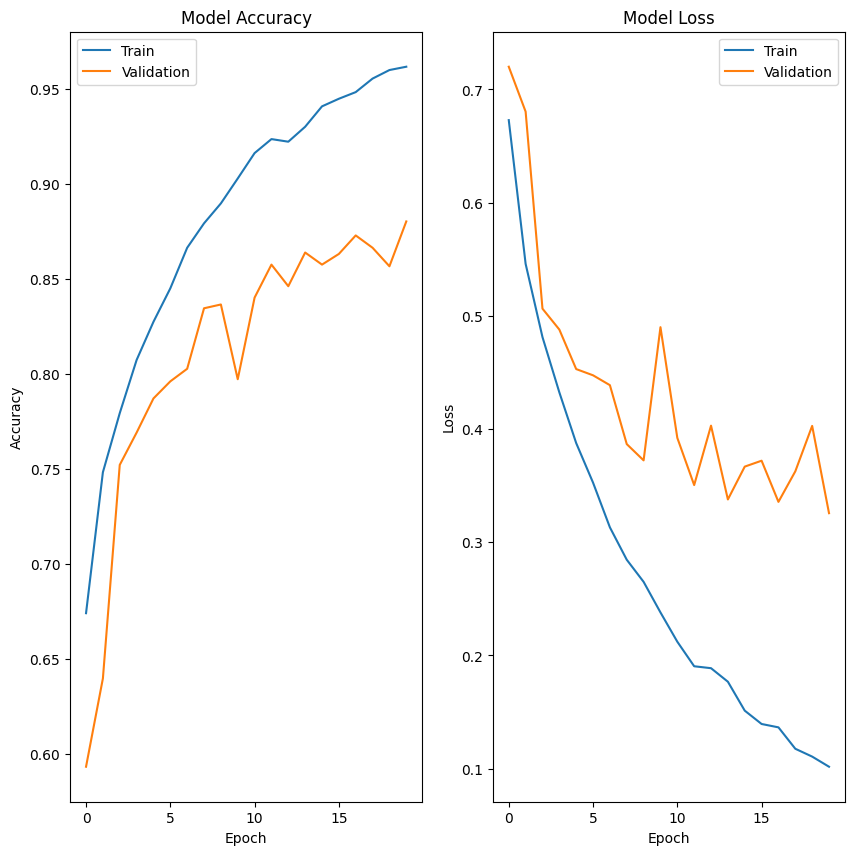

In [22]:
# Plotting Results
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history[f'val_accuracy'])
plt.title(f'Model Accuracy')
plt.ylabel("Accuracy")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history[f'val_loss'])
plt.title(f'Model Loss')
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [23]:
# Testing Model on test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Best Model - Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

  3/250 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7344 - loss: 0.6948 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7922 - loss: 0.5712
Best Model - Test Loss: 0.5562911033630371, Test Accuracy: 0.7947499752044678
